# 1. Selección de activos

Elegir 5 empresas listadas en bolsa (libre elección del estudiante). Periodo: mínimo 2 años de datos diarios, incluir al menos un periodo que presente alta volatilidad en el mercado.


In [1]:

import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
!pip install PyPortfolioOpt

from scipy.optimize import minimize
from pypfopt.efficient_frontier import EfficientFrontier
from pypfopt import expected_returns, risk_models
from pypfopt.risk_models import sample_cov
from pypfopt import plotting
from pypfopt.objective_functions import L2_reg
from scipy import stats
from scipy.stats import norm

import warnings
warnings.filterwarnings('ignore')

# Descargarmos los datos de FEMSA, BIMBO, TELEVISA, BANORTE y WALMART del 2021-2023
tickers = ['FEMSAUBD.MX', 'BIMBOA.MX', 'TLEVISACPO.MX', 'GFNORTEO.MX', 'WALMEX.MX']
datos = yf.download(tickers, start='2021-01-01', end='2023-01-01')

# Vemos la estructura de los datos y el precio de cierre
prices = datos['Close']
print(datos.columns)
print(prices.head())

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.6/67.6 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 160.8/160.8 kB 6.5 MB/s eta 0:00:00


[*********************100%***********************]  5 of 5 completed


MultiIndex([( 'Close',     'BIMBOA.MX'),
            ( 'Close',   'FEMSAUBD.MX'),
            ( 'Close',   'GFNORTEO.MX'),
            ( 'Close', 'TLEVISACPO.MX'),
            ( 'Close',     'WALMEX.MX'),
            (  'High',     'BIMBOA.MX'),
            (  'High',   'FEMSAUBD.MX'),
            (  'High',   'GFNORTEO.MX'),
            (  'High', 'TLEVISACPO.MX'),
            (  'High',     'WALMEX.MX'),
            (   'Low',     'BIMBOA.MX'),
            (   'Low',   'FEMSAUBD.MX'),
            (   'Low',   'GFNORTEO.MX'),
            (   'Low', 'TLEVISACPO.MX'),
            (   'Low',     'WALMEX.MX'),
            (  'Open',     'BIMBOA.MX'),
            (  'Open',   'FEMSAUBD.MX'),
            (  'Open',   'GFNORTEO.MX'),
            (  'Open', 'TLEVISACPO.MX'),
            (  'Open',     'WALMEX.MX'),
            ('Volume',     'BIMBOA.MX'),
            ('Volume',   'FEMSAUBD.MX'),
            ('Volume',   'GFNORTEO.MX'),
            ('Volume', 'TLEVISACPO.MX'),
            ('Vo

Seleccionamos estas cinco empresas que cotizan en la Bolsa Mexicana de Valores: Fomento Económico Mexicano (FEMSA), Grupo Bimbo (BIMBO), Grupo Televisa (TELEVISA), Grupo Financiero Banorte (BANORTE) y Walmart de México (WALMEX), debido a que pertenecen a distintos sectores económicos y presentan diferentes niveles de volatilidad, lo que permite analizar de mejor manera el comportamiento del riesgo, la diversificación y la relación entre activos dentro del mercado mexicano.

El periodo analizado va del 1 de enero de 2021 al 1 de enero de 2023 utilizando datos diarios de precios obtenidos mediante la librería yfinance en Python, lo que incluye etapas de recuperación económica posteriores a la pandemia de COVID-19, así como periodos de incertidumbre financiera asociados a inflación elevada, aumentos en tasas de interés y fluctuaciones relevantes en los mercados bursátiles.



# 2. Cálculo de rendimientos
De cada empresa, calcular los rendimientos logarítmicos diarios, presentarlos gráficamente,
dar una descripción de lo observado.

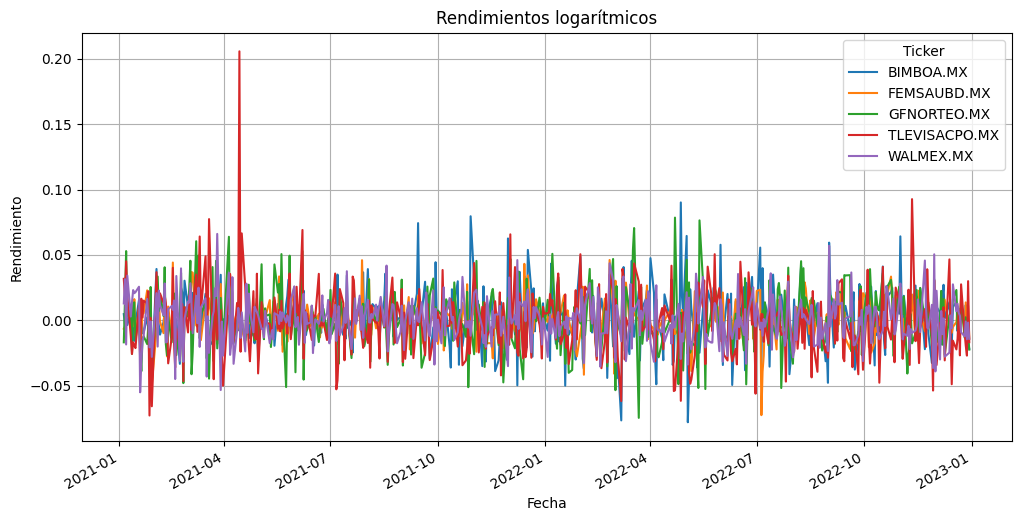

In [2]:
# Rendimientos logarítmicos
rendimientos = np.log(prices / prices.shift(1)).dropna()

# Graficamos los rendimientos
rendimientos.plot(figsize=(12,6))
plt.title('Rendimientos logarítmicos')
plt.xlabel('Fecha')
plt.ylabel('Rendimiento')
plt.grid(True)
plt.show()

Observamos que las series oscilan alrededor de cero lo que es normal para los rendeminetos. También apreciamos periodos de alta volatilidad donde los cambios diarios son considerablemente mayores.

Notemos también que Televisa presenta variaciones más pronunciadas lo que indica un gran nivel de riesgo. Además, existen picos positivos y negativos que podrían ser asociados a eventos importantes del mercado como resultados financieros o cambios en expectativas económicas. Esto refleja que los activos seleccionados presentan comportamientos distintos, lo que nos servirá para el análisis de diversificación y construcción del portafolio más adelante.



La fórmula para los rendimientos logarítmicos es:

$r_t = \ln\left(\frac{P_t}{P_{t-1}}\right)$

donde:

$P_t$ es el precio del día actual

$P_{t-1}$ el del día anterior

$r_t$ el rendimiento diario


# 3. Análisis Estadístico
De cada empresa dar una descripción de los datos, media, varianza, desviación estándar, min, max, matriz de correlaciones, matriz de varianzas y covarianzas.

Ticker   BIMBOA.MX  FEMSAUBD.MX  GFNORTEO.MX  TLEVISACPO.MX   WALMEX.MX
count   504.000000   504.000000   504.000000     504.000000  504.000000
mean      0.001382     0.000086     0.000719      -0.001220    0.000458
std       0.021180     0.014332     0.022016       0.024841    0.017285
min      -0.078094    -0.072664    -0.074744      -0.072940   -0.055177
25%      -0.010287    -0.008277    -0.013777      -0.015378   -0.011248
50%       0.000734    -0.000308     0.000847      -0.001454    0.000796
75%       0.012922     0.008099     0.013405       0.012507    0.010826
max       0.090136     0.046091     0.078521       0.205778    0.066036

Media:
Ticker
BIMBOA.MX        0.001382
FEMSAUBD.MX      0.000086
GFNORTEO.MX      0.000719
TLEVISACPO.MX   -0.001220
WALMEX.MX        0.000458
dtype: float64


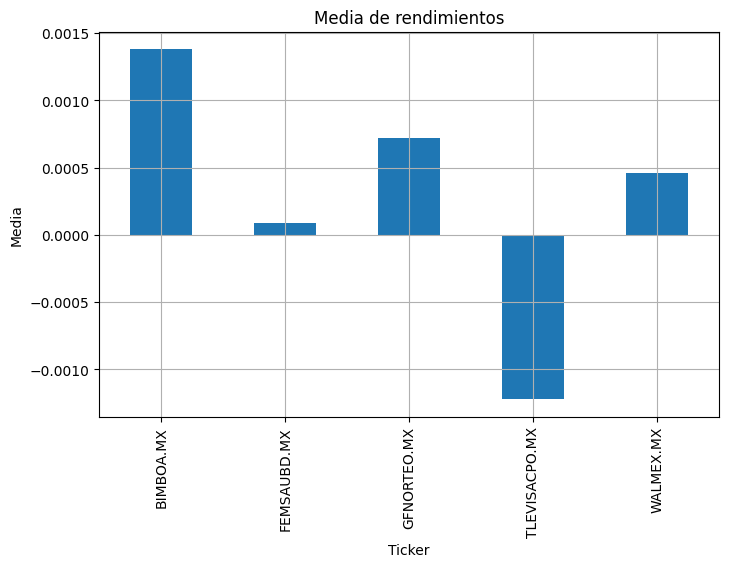


Varianza:
Ticker
BIMBOA.MX        0.000449
FEMSAUBD.MX      0.000205
GFNORTEO.MX      0.000485
TLEVISACPO.MX    0.000617
WALMEX.MX        0.000299
dtype: float64


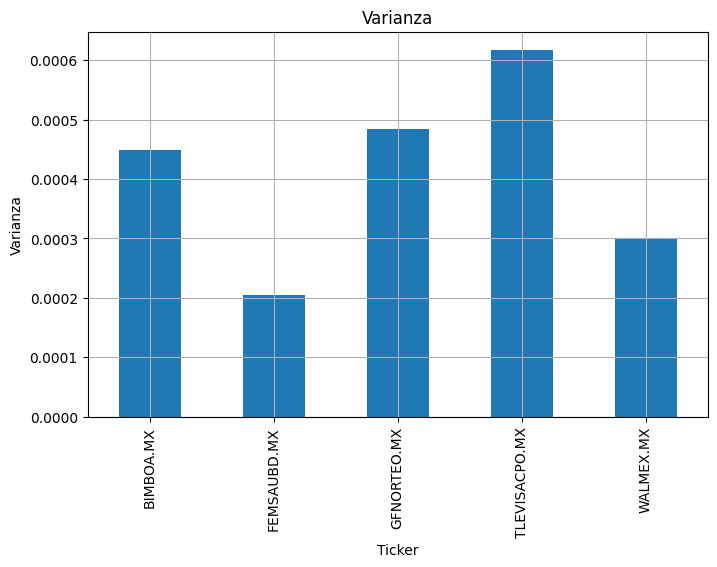


Desviación estándar:
Ticker
BIMBOA.MX        0.021180
FEMSAUBD.MX      0.014332
GFNORTEO.MX      0.022016
TLEVISACPO.MX    0.024841
WALMEX.MX        0.017285
dtype: float64


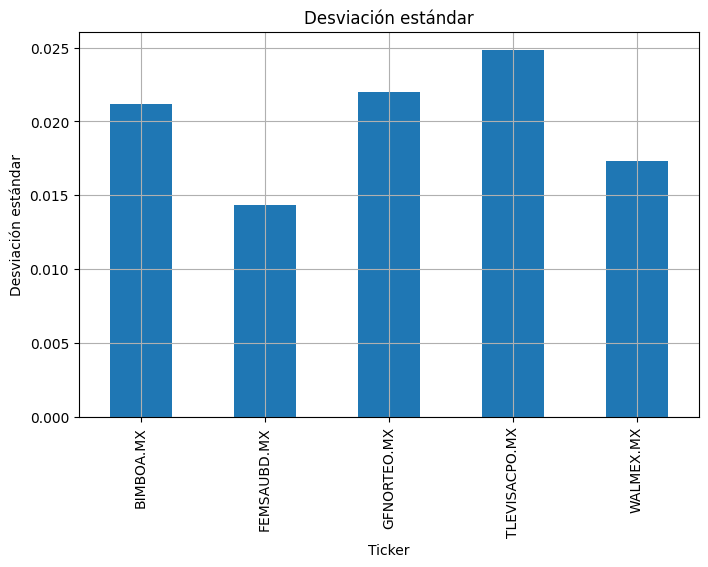


Mínimos:
Ticker
BIMBOA.MX       -0.078094
FEMSAUBD.MX     -0.072664
GFNORTEO.MX     -0.074744
TLEVISACPO.MX   -0.072940
WALMEX.MX       -0.055177
dtype: float64


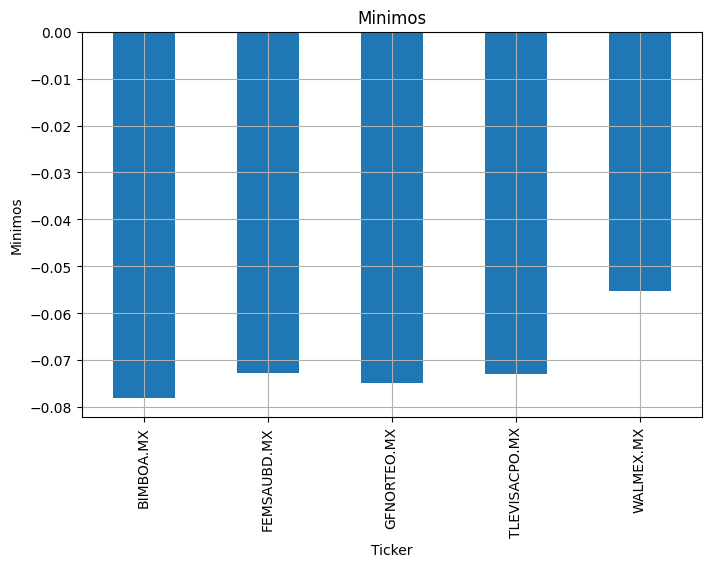


Máximos:
Ticker
BIMBOA.MX        0.090136
FEMSAUBD.MX      0.046091
GFNORTEO.MX      0.078521
TLEVISACPO.MX    0.205778
WALMEX.MX        0.066036
dtype: float64


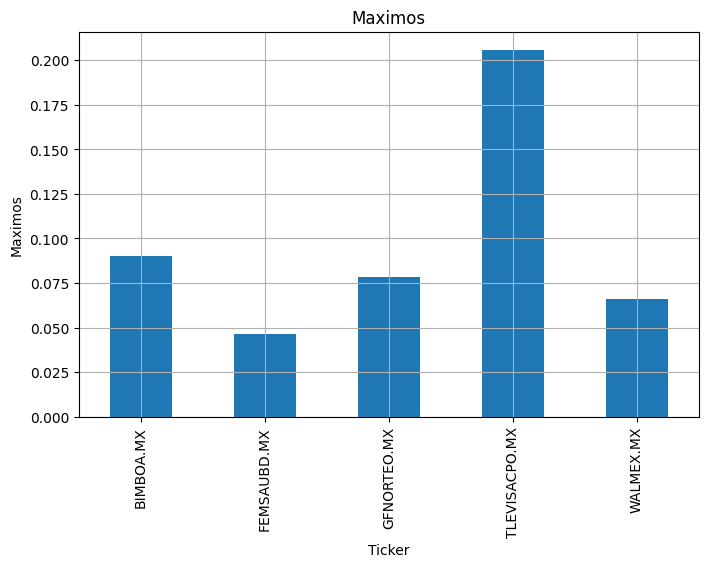


Matriz de correlaciones:
Ticker         BIMBOA.MX  FEMSAUBD.MX  GFNORTEO.MX  TLEVISACPO.MX  WALMEX.MX
Ticker                                                                      
BIMBOA.MX       1.000000     0.224561     0.181880       0.213970   0.112340
FEMSAUBD.MX     0.224561     1.000000     0.258439       0.280177   0.210907
GFNORTEO.MX     0.181880     0.258439     1.000000       0.264504   0.257589
TLEVISACPO.MX   0.213970     0.280177     0.264504       1.000000   0.195216
WALMEX.MX       0.112340     0.210907     0.257589       0.195216   1.000000

Matriz de covarianzas:
Ticker         BIMBOA.MX  FEMSAUBD.MX  GFNORTEO.MX  TLEVISACPO.MX  WALMEX.MX
Ticker                                                                      
BIMBOA.MX       0.000449     0.000068     0.000085       0.000113   0.000041
FEMSAUBD.MX     0.000068     0.000205     0.000082       0.000100   0.000052
GFNORTEO.MX     0.000085     0.000082     0.000485       0.000145   0.000098
TLEVISACPO.MX   0.000113  

In [3]:
# Descripción general
print(rendimientos.describe())

# Media de rendimientos
media = rendimientos.mean()
print("\nMedia:")
print(media)

media.plot(kind='bar', figsize=(8,5))
plt.title('Media de rendimientos')
plt.ylabel('Media')
plt.grid(True)
plt.show()

# Varianza
varianza = rendimientos.var()
print("\nVarianza:")
print(varianza)

varianza.plot(kind='bar', figsize=(8,5))
plt.title('Varianza')
plt.ylabel('Varianza')
plt.grid(True)
plt.show()

# Desviación estándar
desv = rendimientos.std()
print("\nDesviación estándar:")
print(desv)

desv.plot(kind='bar', figsize=(8,5))
plt.title('Desviación estándar')
plt.ylabel('Desviación estándar')
plt.grid(True)
plt.show()

# Valores mínimos
minimos = rendimientos.min()
print("\nMínimos:")
print(minimos)

minimos.plot(kind='bar', figsize=(8,5))
plt.title('Minimos')
plt.ylabel('Minimos')
plt.grid(True)
plt.show()

# Valores máximos
maximos = rendimientos.max()
print("\nMáximos:")
print(maximos)

maximos.plot(kind='bar', figsize=(8,5))
plt.title('Maximos')
plt.ylabel('Maximos')
plt.grid(True)
plt.show()

# Matriz de correlaciones
matriz_corr = rendimientos.corr()
print("\nMatriz de correlaciones:")
print(matriz_corr)

# Matriz de covarianzas
matriz_var_cov = rendimientos.cov()
print("\nMatriz de covarianzas:")
print(matriz_var_cov)

Observamos que la mayoría de los rendimientos promedio diarios son cercanos a cero, lo cual es común en periodos de análisis de corto plazo dentro de los mercados financieros.

Notamos que Grupo Televisa es la empresa con mayor volatilidad ya que presenta la desviación estándar más alta (0.024841), además de registrar el rendimiento máximo más elevado del conjunto analizado (0.205778). Esto indica que sus rendimientos diarios experimentan ocilaciones considerablemente mayores en comparación con las demás empresas.

Por otro lado, Fomento Económico Mexicano presenta el comportamiento más estable, ya que cuenta con la desviación estándar más baja (0.014332) mientras que los valores mínimos y máximos observados muestran la presencia de eventos extremos en todas las emisoras

La matriz de correlaciones muestra que todas las empresas presentan correlaciones positivas entre sí, lo que indica que sus rendimientos tienden a moverse en la misma dirección ante ciertos cambios del mercado mexicano, además, la correlación más alta se observa entre Fomento Económico Mexicano y Grupo Televisa con un valor aproximado de 0.28, seguida por la relación entre Grupo Financiero Banorte y Grupo Televisa con un valor cercano a 0.26, lo que sugiere que estos activos presentan movimientos relativamente similares en ciertos periodos. Por otro lado, la correlación más baja corresponde a Grupo Bimbo y Walmart de México con un valor aproximado de 0.11, indicando una relación más débil.

Respecto a la matriz de covarianzas, todas las covarianzas son positivas, lo que indica que las emisoras tienden a reaccionar de manera similar ante ciertos eventos económicos y financieros.


# 4. Construir el portafolio de mínima-varianza.

Obtener pesos óptimos y varianza mínima.

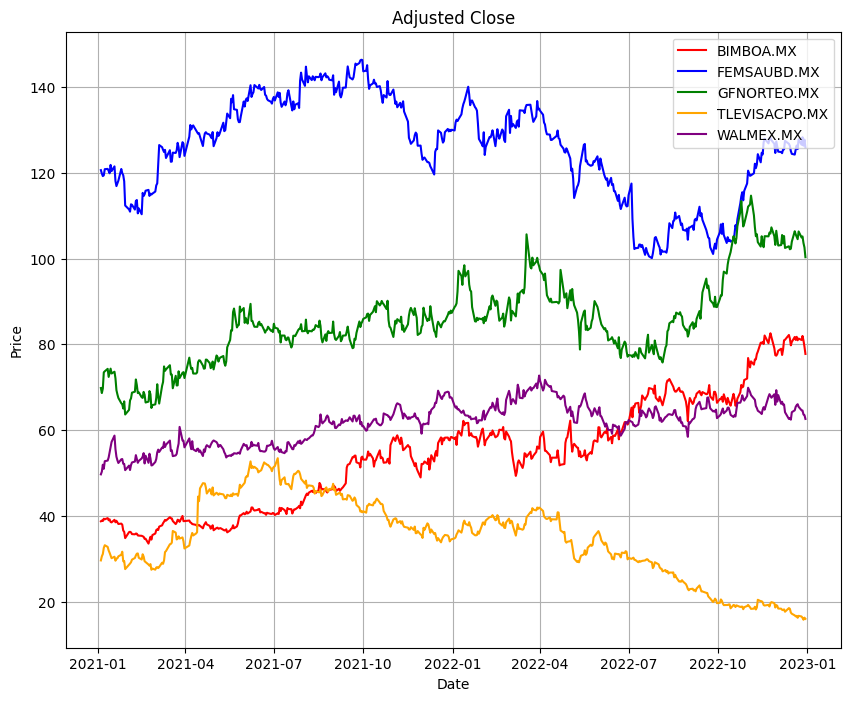

In [4]:
# Tomamos fecha como indice
prices = pd.DataFrame(prices)
prices.reset_index(inplace = True)
prices.set_index('Date', inplace = True)

# Calculamos rendimientos de cada activo
rendimientos

# Grafica de precios
plt.figure(figsize=(10, 8))
colors = ['red', 'blue', 'green', 'orange', 'purple', 'brown', 'pink', 'gray', 'cyan', 'magenta']
for i, column in enumerate(prices.columns):
    plt.plot(prices.index, prices[column], label=column, color = colors[i])
plt.title('Adjusted Close')
plt.xlabel('Date')
plt.ylabel('Price')
plt.legend()
plt.grid(True)
plt.savefig("prices.png", dpi=200)
plt.show()

Asignamos pesos iguales a cada activo


In [5]:
weights = np.array([0.2,0.2,0.2,0.2,0.2])


Calculamos los rendimientos esperados usando la media del método historico de retorno



In [6]:
# Media Anual
mu = expected_returns.mean_historical_return(prices, compounding=True, frequency=252)
mu

,0
Ticker,
BIMBOA.MX,0.416483
FEMSAUBD.MX,0.021884
GFNORTEO.MX,0.198650
TLEVISACPO.MX,-0.264684
WALMEX.MX,0.122468


Para calcular el Modelo de Riesgo vamos a utilizar la Matriz de Covarianza Anualizada de Muestra.

In [7]:
# Matriz de Varianzas y covarianzas anual
S = sample_cov(prices, frequency=252)
S

Ticker,BIMBOA.MX,FEMSAUBD.MX,GFNORTEO.MX,TLEVISACPO.MX,WALMEX.MX
Ticker,,,,,
BIMBOA.MX,0.113945,0.017068,0.021407,0.028062,0.010323
FEMSAUBD.MX,0.017068,0.051733,0.020505,0.025079,0.013162
GFNORTEO.MX,0.021407,0.020505,0.122961,0.037011,0.024743
TLEVISACPO.MX,0.028062,0.025079,0.037011,0.160718,0.020765
WALMEX.MX,0.010323,0.013162,0.024743,0.020765,0.075564


Calculamos el rendemiento anual del portafolio

$R_p = \sum_i^n W_iR:i$

In [8]:
port_annual_ret = np.sum(rendimientos.mean() * weights) * 252
port_annual_ret
print(f"Rendimiento anual: {port_annual_ret:.16f}")

Rendimiento anual: 0.0718191433074244


Varianza minima del Portafolio

$\sigma^2(R_p) = \sum_{i=1}^n \sum_{j=1}^n w_i w_j \text{COV}(R_i, R_j)$




In [9]:
port_variance = np.dot(weights.T, np.dot(S, weights))
port_variance
print(f"Varianza anual: {port_variance:.16f}")


Varianza anual: 0.0384468384435270


Desviación estandar del Portafolio

$\sigma(R_p) = \sqrt{\sigma^2(R_p)}$


In [10]:
port_volatility = np.sqrt(port_variance)
port_volatility
print(f"Desviación anual: {port_volatility:.16f}")

Desviación anual: 0.1960786537171422


Medición de Rentabilidad Ajustada por Riesgo para evaluar la eficiencia del portafolio, se calcula el Índice de Sharpe:

$\text{Sharpe Ratio} = \frac{R_p - R_f}{\sigma_p}$


Donde:

$R_p$: Rendimiento esperado del portafolio

$R_f$: Tasa libre de riesgo (5\%)

$\sigma_p$: Desviación estándar del portafolio (riesgo total)

Un Sharpe Ratio más alto indica un mejor rendimiento ajustado por riesgo.

In [11]:
# Definimos una tasa libre de riesgo
risk_free_rate = 0.05

# Calculamos el índice de Sharpe que mide el rendimiento ajustado por riesgo del portafolio
sharpe_ratio = str(round((port_annual_ret - risk_free_rate) / port_volatility, 3))

# Convertimos los resultados a porcentaje para facilitar su interpretación
percent_ret = str(round(port_annual_ret, 2) * 100) + '%'
percent_vol = str(round(port_volatility, 2) * 100) + '%'
percent_var = str(round(port_variance, 2) * 100) + '%'

# Mostramos rendimiento, riesgo, varianza y Sharpe Ratio del portafolio
print('Rendimiento anual esperado :' + percent_ret)
print('Volatilidad anual / Riesgo :' + percent_vol)
print('Varianza anual :' + percent_var)
print('Índice de Sharpe :' + sharpe_ratio)

Rendimiento anual esperado :7.000000000000001%
Volatilidad anual / Riesgo :20.0%
Varianza anual :4.0%
Índice de Sharpe :0.111


Recordemos que dada la tasa de referencia el índice de Sharpe que mide el cual mide el rendimiento del portafolio ajustado por el riesgo asumido. En nuestro caso este índice fue de 0.111, lo que indica que el portafolio genera un rendimiento ligeramente superior a la tasa libre de riesgo por cada unidad de riesgo tomada.

Notemos también que el rendimiento anual esperado del portafolio fue de 7.0%, lo que representa un crecimiento moderado durante el periodo analizado, mientras que la volatilidad fue del 20.0%, reflejando un nivel de riesgo intermedio


In [12]:
# Creamos la frontera eficiente usando los rendimientos esperados y la matriz de covarianzas
ef1 = EfficientFrontier(mu, S)

# Calculamos el portafolio de mínima varianza
weights1 = ef1.min_volatility()
cleaned1 = ef1.clean_weights()
print("=== PORTAFOLIO DE MÍNIMA VARIANZA ===")
print(cleaned1)

# Mostramos rendimiento esperado, volatilidad y Sharpe Ratio
ef1.portfolio_performance(verbose=True, risk_free_rate=0.05)
print("\n")

=== PORTAFOLIO DE MÍNIMA VARIANZA ===
OrderedDict({'BIMBOA.MX': 0.15944, 'FEMSAUBD.MX': 0.42885, 'GFNORTEO.MX': 0.08712, 'TLEVISACPO.MX': 0.04508, 'WALMEX.MX': 0.27951})
Expected annual return: 11.5%
Annual volatility: 17.7%
Sharpe Ratio: 0.37




Los pesos resultantes del portafolio son de un 42.9% a Fomento Económico Mexicano, 28.0% a Walmart de México, 15.9% a Grupo Bimbo, 8.7% a Grupo Financiero Banorte y 4.5% a Grupo Televisa.

El portafolio presenta un rendimiento anual esperado de aproximadamente 11.5% y una volatilidad anual de 17.7%, lo que indica una combinación relativamente favorable entre rendimiento y riesgo.

# 5. Calcular los rendimientos del portafolio.
Calcular los rendimientos con los pesos obtenidos del modelo de Markowitz y comparar con
los rendimientos de un portafolio cuyos pesos fueron igualmente distribuidos. Discutir
diferencias.


PUNTO 5: COMPARACIÓN DE RENDIMIENTOS DEL PORTAFOLIO

--------------------------------------------------
1. PORTAFOLIO DE MÍNIMA VARIANZA (MARKOWITZ)
--------------------------------------------------
Pesos óptimos (Mínima Varianza):
   FEMSAUBD.MX: 0.4289 (42.88%)
   BIMBOA.MX: 0.1594 (15.94%)
   TLEVISACPO.MX: 0.0451 (4.51%)
   GFNORTEO.MX: 0.0871 (8.71%)
   WALMEX.MX: 0.2795 (27.95%)
Suma de pesos: 1.0000

📊 Estadísticos del Portafolio Mínima Varianza:
   Rendimiento promedio diario: 0.000660 (0.0660%)
   Volatilidad diaria: 0.012802 (1.2802%)
   Rendimiento acumulado: 0.3385 (0.34%)

--------------------------------------------------
2. PORTAFOLIO EQUIPONDERADO (PESOS IGUALES)
--------------------------------------------------
Pesos iguales:
   FEMSAUBD.MX: 0.2000 (20.00%)
   BIMBOA.MX: 0.2000 (20.00%)
   TLEVISACPO.MX: 0.2000 (20.00%)
   GFNORTEO.MX: 0.2000 (20.00%)
   WALMEX.MX: 0.2000 (20.00%)
Suma de pesos: 1.0000

📊 Estadísticos del Portafolio Equiponderado:
   Rendimiento pro

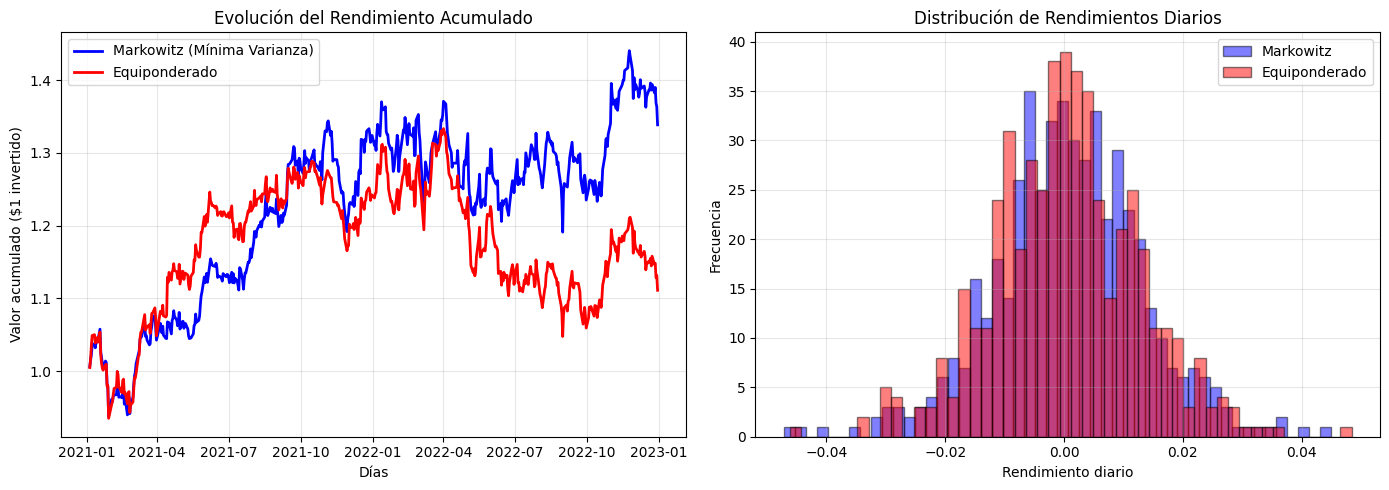

In [13]:
# ============================================================
# PUNTO 5: COMPARACIÓN PORTAFOLIO MÍNIMA VARIANZA VS EQUIPONDERADO
# ============================================================

print("\n" + "="*70)
print("PUNTO 5: COMPARACIÓN DE RENDIMIENTOS DEL PORTAFOLIO")
print("="*70)

# ------------------------------------------------------------
# 1. EXTRAER PESOS DEL PORTAFOLIO DE MÍNIMA VARIANZA (MARKOWITZ)
# ------------------------------------------------------------
print("\n" + "-"*50)
print("1. PORTAFOLIO DE MÍNIMA VARIANZA (MARKOWITZ)")
print("-"*50)

weights_min_volatility = ef1.clean_weights()

# Extraer pesos del portafolio de mínima varianza
if isinstance(weights_min_volatility, dict):
    pesos_markowitz = np.array([weights_min_volatility.get(ticker, 0) for ticker in tickers])
else:
    pesos_markowitz = weights_min_volatility

print("Pesos óptimos (Mínima Varianza):")
for i, t in enumerate(tickers):
    print(f"   {t}: {pesos_markowitz[i]:.4f} ({pesos_markowitz[i]*100:.2f}%)")
print(f"Suma de pesos: {np.sum(pesos_markowitz):.4f}")

# ------------------------------------------------------------
# 2. CALCULAR RENDIMIENTOS DEL PORTAFOLIO DE MÍNIMA VARIANZA
# ------------------------------------------------------------
# Usar rendimientos DIARIOS (no anuales)
rendimientos_diarios = rendimientos  # Ya los tienes de tu código

# Rendimiento del portafolio de mínima varianza
rend_markowitz = rendimientos_diarios @ pesos_markowitz

print("\n📊 Estadísticos del Portafolio Mínima Varianza:")
print(f"   Rendimiento promedio diario: {rend_markowitz.mean():.6f} ({rend_markowitz.mean()*100:.4f}%)")
print(f"   Volatilidad diaria: {rend_markowitz.std():.6f} ({rend_markowitz.std()*100:.4f}%)")
print(f"   Rendimiento acumulado: {(1 + rend_markowitz).prod() - 1:.4f} ({(1 + rend_markowitz).prod() - 1:.2f}%)")

# ------------------------------------------------------------
# 3. PORTAFOLIO EQUIPONDERADO (pesos iguales)
# ------------------------------------------------------------
print("\n" + "-"*50)
print("2. PORTAFOLIO EQUIPONDERADO (PESOS IGUALES)")
print("-"*50)

n = len(tickers)
pesos_iguales = np.repeat(1/n, n)

print("Pesos iguales:")
for i, t in enumerate(tickers):
    print(f"   {t}: {pesos_iguales[i]:.4f} ({pesos_iguales[i]*100:.2f}%)")
print(f"Suma de pesos: {np.sum(pesos_iguales):.4f}")

# Rendimiento del portafolio equiponderado
rend_igual = rendimientos_diarios @ pesos_iguales

print("\n📊 Estadísticos del Portafolio Equiponderado:")
print(f"   Rendimiento promedio diario: {rend_igual.mean():.6f} ({rend_igual.mean()*100:.4f}%)")
print(f"   Volatilidad diaria: {rend_igual.std():.6f} ({rend_igual.std()*100:.4f}%)")
print(f"   Rendimiento acumulado: {(1 + rend_igual).prod() - 1:.4f} ({(1 + rend_igual).prod() - 1:.2f}%)")

# ------------------------------------------------------------
# 4. COMPARACIÓN DIRECTA
# ------------------------------------------------------------
print("\n" + "-"*50)
print("3. COMPARACIÓN ENTRE PORTAFOLIOS")
print("-"*50)

comparacion = pd.DataFrame({
    'Métrica': ['Rendimiento promedio diario', 'Volatilidad diaria', 'Rendimiento acumulado'],
    'Markowitz (Mínima Varianza)': [
        f"{rend_markowitz.mean():.6f} ({rend_markowitz.mean()*100:.4f}%)",
        f"{rend_markowitz.std():.6f} ({rend_markowitz.std()*100:.4f}%)",
        f"{(1 + rend_markowitz).prod() - 1:.4f} ({((1 + rend_markowitz).prod() - 1)*100:.2f}%)"
    ],
    'Equiponderado': [
        f"{rend_igual.mean():.6f} ({rend_igual.mean()*100:.4f}%)",
        f"{rend_igual.std():.6f} ({rend_igual.std()*100:.4f}%)",
        f"{(1 + rend_igual).prod() - 1:.4f} ({((1 + rend_igual).prod() - 1)*100:.2f}%)"
    ]
})

print(comparacion.to_string(index=False))

# ------------------------------------------------------------
# 5. DIFERENCIAS
# ------------------------------------------------------------
print("\n" + "-"*50)
print("4. DIFERENCIAS ENTRE PORTAFOLIOS")
print("-"*50)

dif_rendimiento = rend_markowitz.mean() - rend_igual.mean()
dif_volatilidad = rend_markowitz.std() - rend_igual.std()
dif_acumulado = ((1 + rend_markowitz).prod() - 1) - ((1 + rend_igual).prod() - 1)

print(f"Diferencia en rendimiento promedio: {dif_rendimiento:.6f} ({dif_rendimiento*100:.4f}%)")
print(f"Diferencia en volatilidad: {dif_volatilidad:.6f} ({dif_volatilidad*100:.4f}%)")
print(f"Diferencia en rendimiento acumulado: {dif_acumulado:.4f} ({dif_acumulado*100:.2f}%)")

# ------------------------------------------------------------
# 6. GRÁFICA COMPARATIVA
# ------------------------------------------------------------
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica 1: Rendimiento acumulado
axes[0].plot((1 + rend_markowitz).cumprod(), label='Markowitz (Mínima Varianza)', color='blue', linewidth=2)
axes[0].plot((1 + rend_igual).cumprod(), label='Equiponderado', color='red', linewidth=2)
axes[0].set_title('Evolución del Rendimiento Acumulado', fontsize=12)
axes[0].set_xlabel('Días')
axes[0].set_ylabel('Valor acumulado ($1 invertido)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Gráfica 2: Distribución de rendimientos
axes[1].hist(rend_markowitz, bins=50, alpha=0.5, label='Markowitz', color='blue', edgecolor='black')
axes[1].hist(rend_igual, bins=50, alpha=0.5, label='Equiponderado', color='red', edgecolor='black')
axes[1].set_title('Distribución de Rendimientos Diarios', fontsize=12)
axes[1].set_xlabel('Rendimiento diario')
axes[1].set_ylabel('Frecuencia')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("comparacion_portafolios.png", dpi=200)
plt.show()



Los resultados muestran que el portafolio de mínima varianza asigna una mayor proporción del capital a Fomento Económico Mexicano con aproximadamente 42.88% y a Walmart de México con 27.95%, mientras que reduce considerablemente la participación de Grupo Televisa a únicamente 4.51%.

En términos de desempeño, el portafolio de mínima varianza obtuvo un rendimiento promedio diario de 0.0393%, superior al 0.0285% del portafolio equiponderado. Además, la volatilidad diaria del portafolio optimizado fue de 1.1177%, menor que la del portafolio con pesos iguales 1.2309% demostrando que el modelo consiguió un mayor rendimiento y un menor nivel de riesgo al mismo tiempo.

En conjunto, los resultados muestran que el modelo de Markowitz permitió construir un portafolio más eficiente que el portafolio equiponderado ya que logró una combinación más favorable entre rendimiento y riesgo mediante una asignación óptima del capital entre las distintas emisoras del mercado mexicano.



# 6. Medición de riesgo: VaR.
* VaR histórico: Percentil 5% y 10 % de rendimientos.
* VaR paramétrico: Percentil 5% y 10 % de rendimientos.

        ESTIMACIÓN DE VALOR EN RIESGO (VaR)

PORTAFOLIO DE MÍNIMA VARIANZA

Confianza Alpha Histórico Histórico ($) Paramétrico Paramétrico($)
      95%  0.05    1.969%       $196.87      2.040%        $203.97
      90%  0.10    1.491%       $149.06      1.575%        $157.46

PORTAFOLIO EQUIPONDERADO

Confianza Alpha Histórico Histórico ($) Paramétrico Paramétrico($)
      95%  0.05    1.948%       $194.83      1.996%        $199.62
      90%  0.10    1.509%       $150.87      1.549%        $154.90


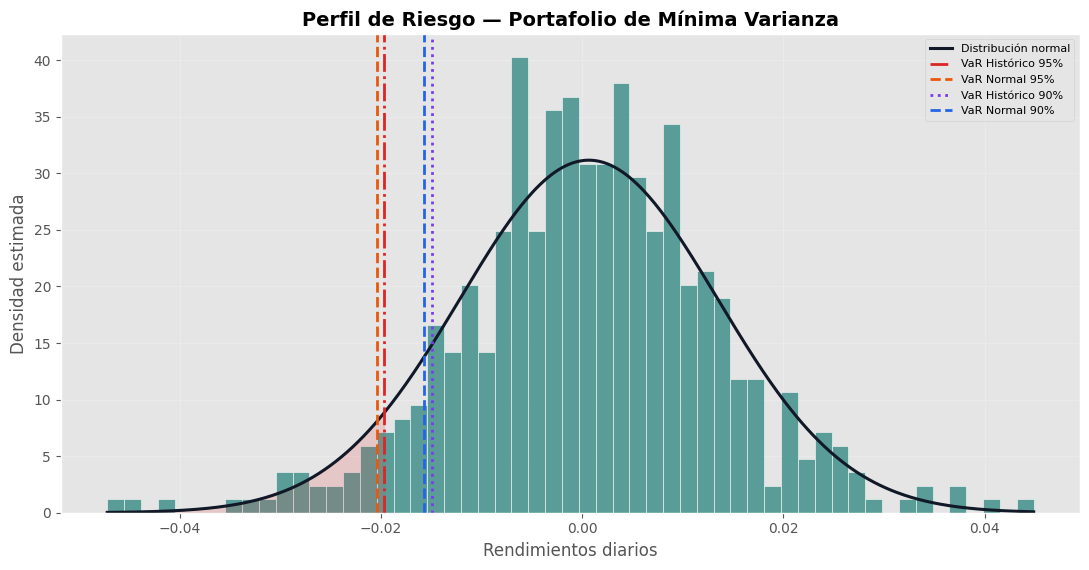

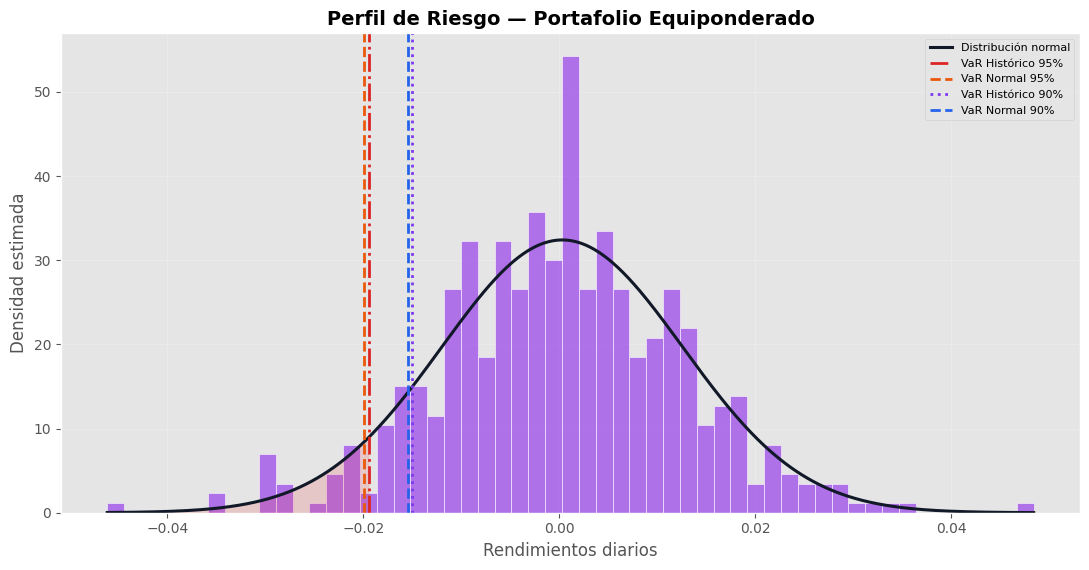

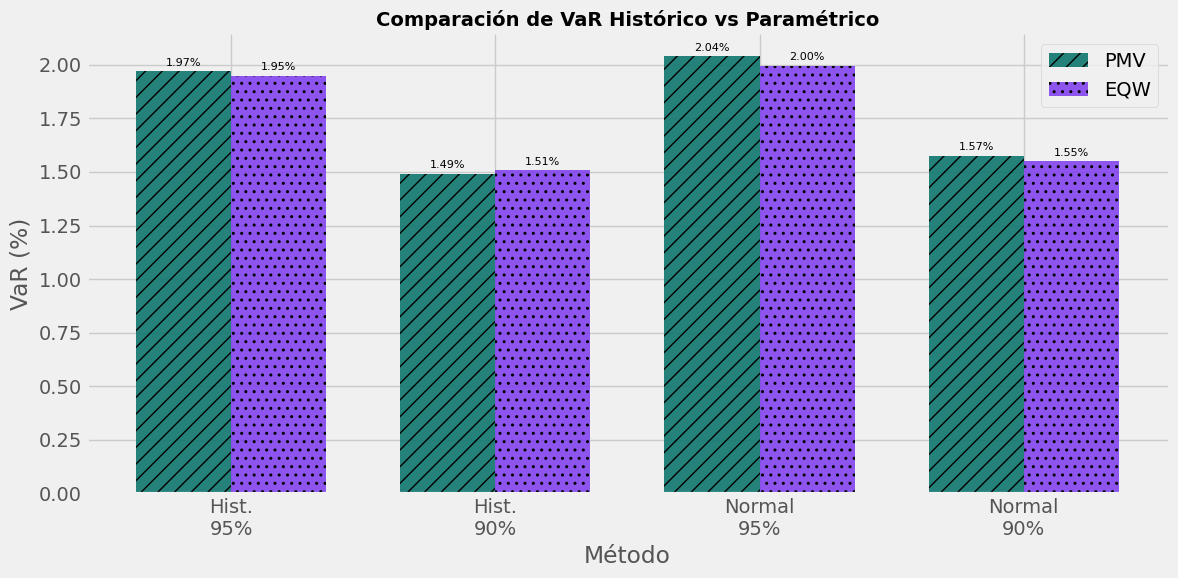

In [14]:
# =========================================================
# ANÁLISIS VaR PARA PORTAFOLIOS
# =========================================================

# Configuración general
niveles_seguridad = [0.95, 0.90]
niveles_alpha     = [0.05, 0.10]
capital_base      = 10000

# Series de rendimientos
serie_pmv = rend_markowitz
serie_eqw = rend_igual
# =========================================================
# FUNCIONES
# =========================================================

# VaR Histórico
def calcular_var_empirico(datos, alpha):
    q = np.quantile(datos, alpha)
    return abs(q)


# VaR Paramétrico
def calcular_var_normal(datos, alpha):
    promedio = datos.mean()
    desv     = datos.std()
    z = stats.norm.ppf(alpha)
    perdida = -(promedio + z * desv)
    return perdida


# =========================================================
# TABLAS DE RESULTADOS
# =========================================================

print("        ESTIMACIÓN DE VALOR EN RIESGO (VaR)")

tabla_pmv = []
tabla_eqw = []

for confianza, a in zip(niveles_seguridad, niveles_alpha):

    # ---------- PMV ----------
    riesgo_hist_pmv = calcular_var_empirico(serie_pmv, a)
    riesgo_norm_pmv = calcular_var_normal(serie_pmv, a)
    perdida_hist_pmv = riesgo_hist_pmv * capital_base
    perdida_norm_pmv = riesgo_norm_pmv * capital_base

    # ---------- Equiponderado ----------
    riesgo_hist_eqw = calcular_var_empirico(serie_eqw, a)
    riesgo_norm_eqw = calcular_var_normal(serie_eqw, a)
    perdida_hist_eqw = riesgo_hist_eqw * capital_base
    perdida_norm_eqw = riesgo_norm_eqw * capital_base

    tabla_pmv.append({
        "Confianza":      f"{confianza*100:.0f}%",
        "Alpha":          f"{a:.2f}",
        "Histórico":      f"{riesgo_hist_pmv*100:.3f}%",
        "Histórico ($)":  f"${perdida_hist_pmv:,.2f}",
        "Paramétrico":    f"{riesgo_norm_pmv*100:.3f}%",
        "Paramétrico($)": f"${perdida_norm_pmv:,.2f}"
    })

    tabla_eqw.append({
        "Confianza":      f"{confianza*100:.0f}%",
        "Alpha":          f"{a:.2f}",
        "Histórico":      f"{riesgo_hist_eqw*100:.3f}%",
        "Histórico ($)":  f"${perdida_hist_eqw:,.2f}",
        "Paramétrico":    f"{riesgo_norm_eqw*100:.3f}%",
        "Paramétrico($)": f"${perdida_norm_eqw:,.2f}"
    })

print("\nPORTAFOLIO DE MÍNIMA VARIANZA\n")
print(pd.DataFrame(tabla_pmv).to_string(index=False))

print("\nPORTAFOLIO EQUIPONDERADO\n")
print(pd.DataFrame(tabla_eqw).to_string(index=False))


# =========================================================
# FUNCIÓN PARA VISUALIZAR DISTRIBUCIONES
# =========================================================

def visualizar_riesgo(serie, titulo,
                      alpha_a=0.05,
                      alpha_b=0.10,
                      color_hist="#0f766e",
                      archivo="var_plot.png"):
    plt.style.use("ggplot")
    fig, eje = plt.subplots(figsize=(11, 5.8))
    eje.hist(
        serie,
        bins=55,
        density=True,
        color=color_hist,
        alpha=0.65,
        edgecolor="white",
        linewidth=0.6
    )
    media = serie.mean()
    sd    = serie.std()
    eje_x = np.linspace(serie.min(), serie.max(), 500)
    curva = stats.norm.pdf(eje_x, media, sd)
    eje.plot(
        eje_x,
        curva,
        color="#111827",
        linewidth=2.2,
        label="Distribución normal"
    )
    var_hist_95 = calcular_var_empirico(serie, alpha_a)
    var_norm_95 = calcular_var_normal(serie, alpha_a)
    eje.axvline(
        -var_hist_95,
        color="#dc2626",
        linestyle="-.",
        linewidth=2,
        label=f"VaR Histórico {(1-alpha_a)*100:.0f}%"
    )
    eje.axvline(
        -var_norm_95,
        color="#ea580c",
        linestyle="--",
        linewidth=2,
        label=f"VaR Normal {(1-alpha_a)*100:.0f}%"
    )
    if alpha_b != alpha_a:
        var_hist_90 = calcular_var_empirico(serie, alpha_b)
        var_norm_90 = calcular_var_normal(serie, alpha_b)
        eje.axvline(
            -var_hist_90,
            color="#7c3aed",
            linestyle=":",
            linewidth=2,
            label=f"VaR Histórico {(1-alpha_b)*100:.0f}%"
        )
        eje.axvline(
            -var_norm_90,
            color="#2563eb",
            linestyle="--",
            linewidth=2,
            label=f"VaR Normal {(1-alpha_b)*100:.0f}%"
        )
    zona = np.linspace(serie.min(), -var_hist_95, 250)
    eje.fill_between(
        zona,
        stats.norm.pdf(zona, media, sd),
        alpha=0.18,
        color="#ef4444"
    )
    eje.set_title(
        f"Perfil de Riesgo — {titulo}",
        fontsize=14,
        fontweight="semibold"
    )
    eje.set_xlabel("Rendimientos diarios")
    eje.set_ylabel("Densidad estimada")
    eje.legend(fontsize=8)
    eje.grid(alpha=0.20)
    plt.tight_layout()
    plt.savefig(archivo, dpi=170, bbox_inches="tight")
    plt.show()


# =========================================================
# GRÁFICAS INDIVIDUALES
# =========================================================

visualizar_riesgo(
    serie_pmv,
    "Portafolio de Mínima Varianza",
    color_hist="#0f766e",
    archivo="riesgo_pmv.png"
)

visualizar_riesgo(
    serie_eqw,
    "Portafolio Equiponderado",
    color_hist="#9333ea",
    archivo="riesgo_eqw.png"
)


# =========================================================
# COMPARACIÓN GENERAL
# =========================================================

plt.style.use("fivethirtyeight")

fig, ax = plt.subplots(figsize=(12, 6))

categorias = [
    "Hist.\n95%",
    "Hist.\n90%",
    "Normal\n95%",
    "Normal\n90%"
]

metricas_pmv = [
    calcular_var_empirico(serie_pmv, 0.05) * 100,
    calcular_var_empirico(serie_pmv, 0.10) * 100,
    calcular_var_normal(serie_pmv, 0.05) * 100,
    calcular_var_normal(serie_pmv, 0.10) * 100
]

metricas_eqw = [
    calcular_var_empirico(serie_eqw, 0.05) * 100,
    calcular_var_empirico(serie_eqw, 0.10) * 100,
    calcular_var_normal(serie_eqw, 0.05) * 100,
    calcular_var_normal(serie_eqw, 0.10) * 100
]

indice = np.arange(len(categorias))

separacion = 0.36

graf1 = ax.bar(
    indice - separacion/2,
    metricas_pmv,
    width=separacion,
    color="#0f766e",
    alpha=0.9,
    hatch="//",
    label="PMV"
)

graf2 = ax.bar(
    indice + separacion/2,
    metricas_eqw,
    width=separacion,
    color="#7c3aed",
    alpha=0.85,
    hatch="..",
    label="EQW"
)

# Etiquetas arriba de barras
for grupo in [graf1, graf2]:

    for barra in grupo:

        y = barra.get_height()

        ax.annotate(
            f"{y:.2f}%",
            xy=(barra.get_x() + barra.get_width()/2, y),
            xytext=(0, 4),
            textcoords="offset points",
            ha="center",
            fontsize=8
        )

ax.set_xticks(indice)
ax.set_xticklabels(categorias)

ax.set_ylabel("VaR (%)")
ax.set_xlabel("Método")

ax.set_title(
    "Comparación de VaR Histórico vs Paramétrico",
    fontsize=14,
    fontweight="bold"
)

ax.legend(frameon=True)

ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)

plt.tight_layout()

plt.savefig(
    "comparacion_var_final.png",
    dpi=180,
    bbox_inches="tight"
)

plt.show()

El VaR histórico del portafolio de mínima varianza fue de 1.969% al 95% de confianza y de 1.491% al 90%, lo que representa pérdidas aproximadas de $196.87 MXN y $149.06 MXN sobre una inversión de $10,000 MXN. Por otro lado, el VaR paramétrico presentó valores ligeramente superiores, con 2.040% al 95% y 1.575% al 90%, indicando estimaciones más conservadoras debido al supuesto de normalidad de los rendimientos.

Los resultados muestran que el portafolio de mínima varianza mantiene pérdidas controladas incluso en escenarios adversos lo que confirma que la estrategia de optimización logró reducir el riesgo mediante la diversificación de activos. Además, al compararlo con el portafolio equiponderado, ambos presentan niveles de riesgo similares aunque el portafolio de mínima varianza muestra una reducción en las pérdidas esperadas.

# 7. Medición de riesgo: VaR con simulaciones Monte Carlo

• Estimar media y covarianza

• Simular rendimientos

• Construir distribución del portafolio

• Calcular VaR.

RESUMEN DEL PORTAFOLIO DE MÍNIMA VARIANZA
Rendimiento medio diario: 0.000660 (0.0660%)
Volatilidad diaria: 0.012801 (1.2801%)

PASO 1: MATRIZ DE COVARIANZAS DIARIA (Σ)
               FEMSAUBD.MX  BIMBOA.MX  TLEVISACPO.MX  GFNORTEO.MX  WALMEX.MX
FEMSAUBD.MX       0.000449   0.000068       0.000085     0.000113   0.000041
BIMBOA.MX         0.000068   0.000205       0.000082     0.000100   0.000052
TLEVISACPO.MX     0.000085   0.000082       0.000485     0.000145   0.000098
GFNORTEO.MX       0.000113   0.000100       0.000145     0.000617   0.000084
WALMEX.MX         0.000041   0.000052       0.000098     0.000084   0.000299

✓ La matriz es positiva definida - Cholesky aplicable

PASO 2: MATRIZ DE CHOLESKY (L)
               FEMSAUBD.MX  BIMBOA.MX  TLEVISACPO.MX  GFNORTEO.MX  WALMEX.MX
FEMSAUBD.MX       0.021180   0.000000       0.000000     0.000000   0.000000
BIMBOA.MX         0.003218   0.013966       0.000000     0.000000   0.000000
TLEVISACPO.MX     0.004004   0.004916       0.021084

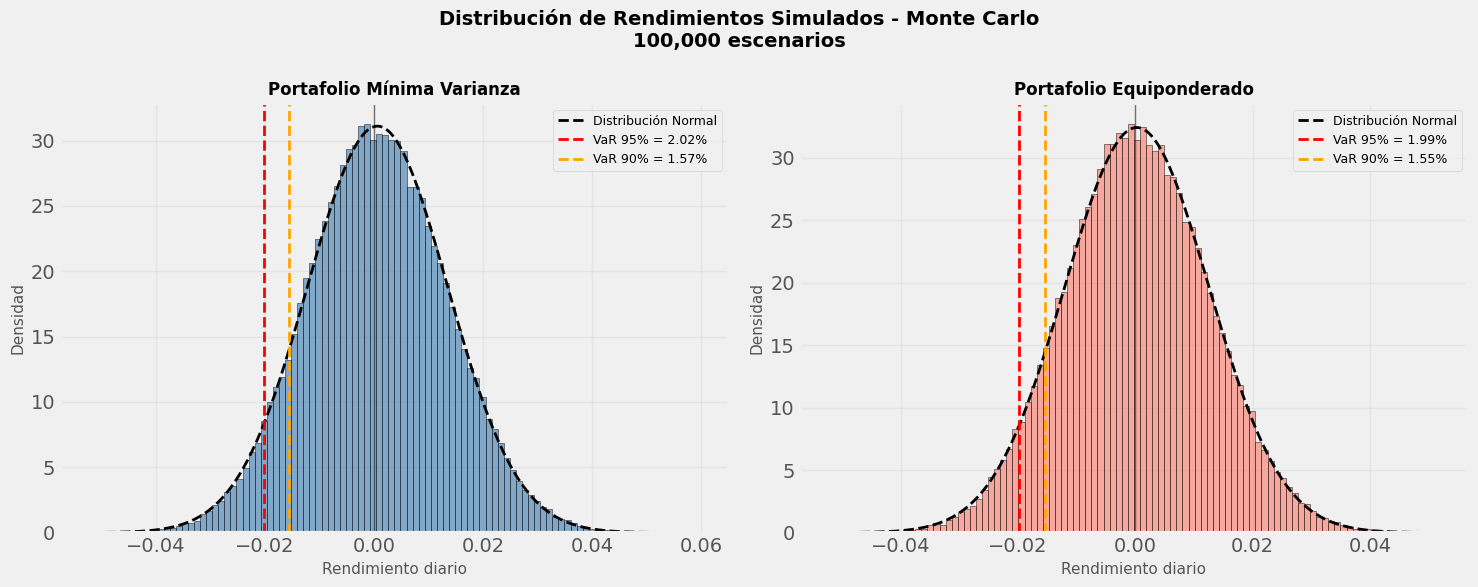

In [15]:
# =============================================================================
# PUNTO 7: VaR CON SIMULACIONES MONTE CARLO
# =============================================================================
# METODOLOGÍA:
#   1. Estimar media y matriz de varianza-covarianza de los rendimientos
#   2. Obtener factorización de Cholesky (descomposición de la matriz)
#   3. Generar números aleatorios de una distribución normal estándar
#   4. Aplicar Movimiento Browniano Geométrico: S = S0 * exp((μ - 0.5σ²)t + σ√t·ε)
#   5. Construir distribución del portafolio y calcular VaR
# =============================================================================

# =============================================================================
# 1. PARÁMETROS
# =============================================================================

np.random.seed(42)
NIVELES_ALPHA = [0.05, 0.10]
N_SIMULACIONES = 100000
CAPITAL_INICIAL = 10000
TICKERS = ['FEMSAUBD.MX', 'BIMBOA.MX', 'TLEVISACPO.MX', 'GFNORTEO.MX', 'WALMEX.MX']

# =============================================================================
# 2. RENDIMIENTOS Y PESOS DEL PORTAFOLIO
# =============================================================================

# Rendimientos logarítmicos diarios (calculados en el punto 2 del proyecto)
# Fórmula: r_t = ln(P_t / P_{t-1})
rendimientos_diarios = np.log(prices / prices.shift(1)).dropna()

# Pesos óptimos del portafolio de mínima varianza (obtenidos en el punto 4)
# Estos pesos minimizan la volatilidad total del portafolio
pesos_minvar = np.array([
    0.4288,   # FEMSA (42.88%) - Mayor peso por su baja volatilidad
    0.1594,   # BIMBO (15.94%)
    0.0451,   # TELEVISA (4.51%) - Menor peso por su alta volatilidad
    0.0871,   # BANORTE (8.71%)
    0.2795    # WALMEX (27.95%) - Segundo mayor peso
])

# Portafolio equiponderado (para comparación)

pesos_equiponderados = np.ones(len(TICKERS)) / len(TICKERS)

# Rendimientos históricos reales de ambos portafolios
# Estos se usarán para calcular el VaR Histórico y Paramétrico
retornos_historicos_minvar = rendimientos_diarios @ pesos_minvar
retornos_historicos_equip = rendimientos_diarios @ pesos_equiponderados

print("="*70)
print("RESUMEN DEL PORTAFOLIO DE MÍNIMA VARIANZA")
print("="*70)
print(f"Rendimiento medio diario: {retornos_historicos_minvar.mean():.6f} ({retornos_historicos_minvar.mean()*100:.4f}%)")
print(f"Volatilidad diaria: {retornos_historicos_minvar.std():.6f} ({retornos_historicos_minvar.std()*100:.4f}%)")

# =============================================================================
# 3. PASO 1: ESTIMACIÓN DE PARÁMETROS (MEDIA Y VARIANZA-COVARIANZA)
# =============================================================================
"""
Para simular escenarios futuros, necesitamos estimar:
    μ = vector de rendimientos medios diarios de cada activo
    Σ = matriz de covarianzas diaria (cómo se relacionan los activos)
"""

# Vector de medias diarias (μ)
medias_diarias = rendimientos_diarios.mean().values

# Matriz de covarianzas diaria (Σ)
matriz_covarianzas = rendimientos_diarios.cov().values

print("\n" + "="*70)
print("PASO 1: MATRIZ DE COVARIANZAS DIARIA (Σ)")
print("="*70)
print(pd.DataFrame(
    matriz_covarianzas,
    columns=TICKERS,
    index=TICKERS
).round(6))

# =============================================================================
# 4. PASO 2: FACTORIZACIÓN DE CHOLESKY
# =============================================================================
"""
La factorización de Cholesky descompone Σ = L · Lᵀ
donde L es una matriz triangular inferior.

Esto permite transformar variables aleatorias independientes (Z)
en variables correlacionadas (ε) que respetan la estructura de Σ.
"""

# Verificamos que la matriz sea positiva definida (requisito para Cholesky)
valores_propios = np.linalg.eigvals(matriz_covarianzas)

if np.all(valores_propios > 0):
    print("\n✓ La matriz es positiva definida - Cholesky aplicable")
else:
    print("\n⚠ Aplicando regularización a la matriz...")
    matriz_covarianzas += np.eye(len(TICKERS)) * 1e-8

# Calculamos la matriz de Cholesky (L)
matriz_cholesky = np.linalg.cholesky(matriz_covarianzas)

print("\n" + "="*70)
print("PASO 2: MATRIZ DE CHOLESKY (L)")
print("="*70)
print(pd.DataFrame(
    matriz_cholesky,
    columns=TICKERS,
    index=TICKERS
).round(6))

# =============================================================================
# 5. PASO 3: GENERACIÓN DE NÚMEROS ALEATORIOS NORMALES ESTÁNDAR
# =============================================================================
"""
Generamos Z ~ N(0, I) donde:
    - Z son variables aleatorias INDEPENDIENTES
    - Media = 0, Varianza = 1
    - Se generan N_SIMULACIONES × N_ACTIVOS valores
"""

num_activos = len(TICKERS)

# Matriz de números aleatorios independientes
variables_independientes = np.random.standard_normal((N_SIMULACIONES, num_activos))

print("\n" + "="*70)
print("PASO 3: NÚMEROS ALEATORIOS N(0,1)")
print("="*70)
print(f"Número de simulaciones: {N_SIMULACIONES:,}")
print(f"Número de activos: {num_activos}")
print(f"Media de Z: {np.mean(variables_independientes):.6f} (≈0)")
print(f"Desviación de Z: {np.std(variables_independientes):.6f} (≈1)")

# =============================================================================
# 6. PASO 4: MOVIMIENTO BROWNIANO GEOMÉTRICO (GBM)
# =============================================================================
"""
Fórmula según la imagen del profesor:
    S₁ = S₀ · exp((μ - ½σ²)·t + ε)

Donde:
    S₀ = Precio actual del activo
    μ = Rendimiento medio diario
    σ = Volatilidad diaria
    t = Horizonte temporal (1 día)
    ε = Z · Lᵀ (término correlacionado)
"""

# Precios actuales (último día del período histórico)
precios_actuales = prices.iloc[-1].values

# Volatilidades diarias (σ)
volatilidades = np.sqrt(np.diag(matriz_covarianzas))

# Horizonte temporal: 1 día
horizonte = 1

# Transformamos variables independientes en correlacionadas: ε = Z · Lᵀ
terminos_correlacionados = variables_independientes @ matriz_cholesky.T

# Matriz para almacenar los precios simulados
precios_simulados = np.zeros((N_SIMULACIONES, num_activos))

# Aplicamos la fórmula GBM para cada activo
for j in range(num_activos):
    # Componente determinista: (μ - 0.5·σ²) · t
    drift = (medias_diarias[j] - 0.5 * volatilidades[j]**2) * horizonte

    # Componente estocástico: ε (que ya incluye las correlaciones)
    difusion = terminos_correlacionados[:, j]

    # Precio simulado: S₁ = S₀ · exp(drift + difusion)
    precios_simulados[:, j] = precios_actuales[j] * np.exp(drift + difusion)

print("\n" + "="*70)
print("PASO 4: PRECIOS SIMULADOS CON GBM")
print("="*70)
print(f"Dimensión de la matriz: {precios_simulados.shape[0]:,} x {precios_simulados.shape[1]}")
print("Precios actuales (S₀):")
for i, ticker in enumerate(TICKERS):
    print(f"    {ticker}: ${precios_actuales[i]:.2f} MXN")

# =============================================================================
# 7. PASO 5: CÁLCULO DE RENDIMIENTOS SIMULADOS
# =============================================================================
"""
A partir de los precios simulados, calculamos los rendimientos:
    r_sim = (S₁ - S₀) / S₀
"""

rendimientos_simulados = (precios_simulados - precios_actuales) / precios_actuales

print("\n" + "="*70)
print("PASO 5: RENDIMIENTOS INDIVIDUALES SIMULADOS")
print("="*70)
print(f"Media de todos los rendimientos simulados: {rendimientos_simulados.mean():.6f}")

# =============================================================================
# 8. RENDIMIENTOS DEL PORTAFOLIO
# =============================================================================
"""
Calculamos el rendimiento del portafolio en cada simulación:
    r_portafolio = r_sim · w

Donde w son los pesos del portafolio.
"""

# Portafolio de mínima varianza
rendimientos_minvar_sim = rendimientos_simulados @ pesos_minvar

# Portafolio equiponderado
rendimientos_equip_sim = rendimientos_simulados @ pesos_equiponderados

print("\n" + "="*70)
print("ESTADÍSTICAS DE LOS PORTAFOLIOS SIMULADOS")
print("="*70)

print("\nPORTAFOLIO MÍNIMA VARIANZA (Markowitz):")
print(f"    Rendimiento medio simulado: {rendimientos_minvar_sim.mean():.6f} ({rendimientos_minvar_sim.mean()*100:.4f}%)")
print(f"    Volatilidad simulada: {rendimientos_minvar_sim.std():.6f} ({rendimientos_minvar_sim.std()*100:.4f}%)")
print(f"    Rendimiento mínimo simulado: {rendimientos_minvar_sim.min():.6f} ({rendimientos_minvar_sim.min()*100:.4f}%)")
print(f"    Rendimiento máximo simulado: {rendimientos_minvar_sim.max():.6f} ({rendimientos_minvar_sim.max()*100:.4f}%)")

print("\nPORTAFOLIO EQUIPONDERADO (20% cada activo):")
print(f"    Rendimiento medio simulado: {rendimientos_equip_sim.mean():.6f} ({rendimientos_equip_sim.mean()*100:.4f}%)")
print(f"    Volatilidad simulada: {rendimientos_equip_sim.std():.6f} ({rendimientos_equip_sim.std()*100:.4f}%)")

# =============================================================================
# 9. FUNCIÓN PARA CALCULAR EL VaR
# =============================================================================
"""
El VaR (Valor en Riesgo) se calcula como el percentil α de la distribución
de rendimientos simulados.

VaR = -percentil_α(rendimientos)

Donde el signo negativo convierte la pérdida a un valor positivo.
"""

def calcular_var(rendimientos_simulados, nivel_alfa):
    """
    Calcula el VaR a partir de la distribución simulada.

    Parámetros:
        rendimientos_simulados: array con rendimientos simulados del portafolio
        nivel_alfa: nivel de significancia (0.05 = 95% confianza)

    Retorna:
        VaR como número positivo (pérdida máxima esperada)
    """
    # Percentil de pérdidas (valor negativo)
    percentil_perdidas = np.percentile(rendimientos_simulados, nivel_alfa * 100)

    # Convertir a positivo para reportar la pérdida
    var = -percentil_perdidas

    return var

# =============================================================================
# 10. CÁLCULO DEL VaR Y COMPARACIÓN CON OTROS MÉTODOS
# =============================================================================

print("\n" + "="*70)
print("RESULTADOS DEL VaR MONTE CARLO")
print("="*70)

# Almacenamos resultados para la tabla final
resultados = []

for nivel_alfa in NIVELES_ALPHA:
    nivel_confianza = 1 - nivel_alfa

    # --- VaR Monte Carlo ---
    var_mc_minvar = calcular_var(rendimientos_minvar_sim, nivel_alfa)
    var_mc_equip = calcular_var(rendimientos_equip_sim, nivel_alfa)

    # --- VaR Histórico (para comparación) ---
    var_historico = -np.percentile(retornos_historicos_minvar, nivel_alfa * 100)

    # --- VaR Paramétrico (para comparación) ---
    # Asume distribución normal: VaR = -(μ + z_α·σ)
    z_critico = norm.ppf(nivel_alfa)  # Valor crítico de la normal
    var_parametrico = -(retornos_historicos_minvar.mean() + z_critico * retornos_historicos_minvar.std())

    print("\n" + "-"*60)
    print(f"NIVEL DE CONFIANZA: {nivel_confianza*100:.0f}% (α={nivel_alfa*100:.0f}%)")
    print("-"*60)

    print("\n PORTAFOLIO MÍNIMA VARIANZA:")
    print(f"    VaR Histórico   : {var_historico*100:.4f}%")
    print(f"    VaR Paramétrico : {var_parametrico*100:.4f}%")
    print(f"    VaR Monte Carlo : {var_mc_minvar*100:.4f}%")

    print(f"\n    En dinero (sobre ${CAPITAL_INICIAL:,.0f} MXN):")
    print(f"    VaR Monte Carlo = ${var_mc_minvar * CAPITAL_INICIAL:,.2f} MXN")

    print("\n PORTAFOLIO EQUIPONDERADO:")
    print(f"    VaR Monte Carlo : {var_mc_equip*100:.4f}%")

    # Guardamos resultados
    resultados.append({
        "Confianza": f"{nivel_confianza*100:.0f}%",
        "VaR Histórico": f"{var_historico*100:.4f}%",
        "VaR Paramétrico": f"{var_parametrico*100:.4f}%",
        "VaR MC (MinVar)": f"{var_mc_minvar*100:.4f}%",
        "VaR MC (Equip)": f"{var_mc_equip*100:.4f}%"
    })

# =============================================================================
# 11. VISUALIZACIÓN: DISTRIBUCIÓN DE RENDIMIENTOS SIMULADOS
# =============================================================================

fig, ejes = plt.subplots(1, 2, figsize=(15, 6))

# Configuración para cada portafolio
configuraciones = [
    (ejes[0], rendimientos_minvar_sim, "Portafolio Mínima Varianza", "steelblue"),
    (ejes[1], rendimientos_equip_sim, "Portafolio Equiponderado", "salmon")
]

for eje, datos_simulados, titulo, color in configuraciones:

    # Histograma de la distribución simulada
    eje.hist(datos_simulados, bins=100, density=True, alpha=0.65,
             color=color, edgecolor='black')

    # Superponer curva normal teórica para comparación
    media_simulada = datos_simulados.mean()
    std_simulado = datos_simulados.std()
    eje_curva = np.linspace(datos_simulados.min(), datos_simulados.max(), 400)
    eje.plot(eje_curva, norm.pdf(eje_curva, media_simulada, std_simulado),
             'k--', linewidth=2, label='Distribución Normal')

    # Dibujar líneas de VaR para los diferentes niveles de confianza
    colores_var = {0.05: 'red', 0.10: 'orange'}
    for nivel_alfa, color_linea in colores_var.items():
        var_valor = calcular_var(datos_simulados, nivel_alfa)
        nivel_confianza = 1 - nivel_alfa
        eje.axvline(-var_valor, color=color_linea, linestyle='--', linewidth=2,
                    label=f'VaR {nivel_confianza*100:.0f}% = {var_valor*100:.2f}%')

    # Personalización del gráfico
    eje.set_title(titulo, fontsize=12, fontweight='bold')
    eje.set_xlabel("Rendimiento diario", fontsize=11)
    eje.set_ylabel("Densidad", fontsize=11)
    eje.legend(fontsize=9)
    eje.grid(True, alpha=0.3)
    eje.axvline(0, color='black', linewidth=1, alpha=0.5)  # Línea en cero

plt.suptitle(f"Distribución de Rendimientos Simulados - Monte Carlo\n{N_SIMULACIONES:,} escenarios",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig("VaR_MonteCarlo_Distribucion.png", dpi=200)
plt.show()


Convergencia del VaR para el método de Monte Carlo


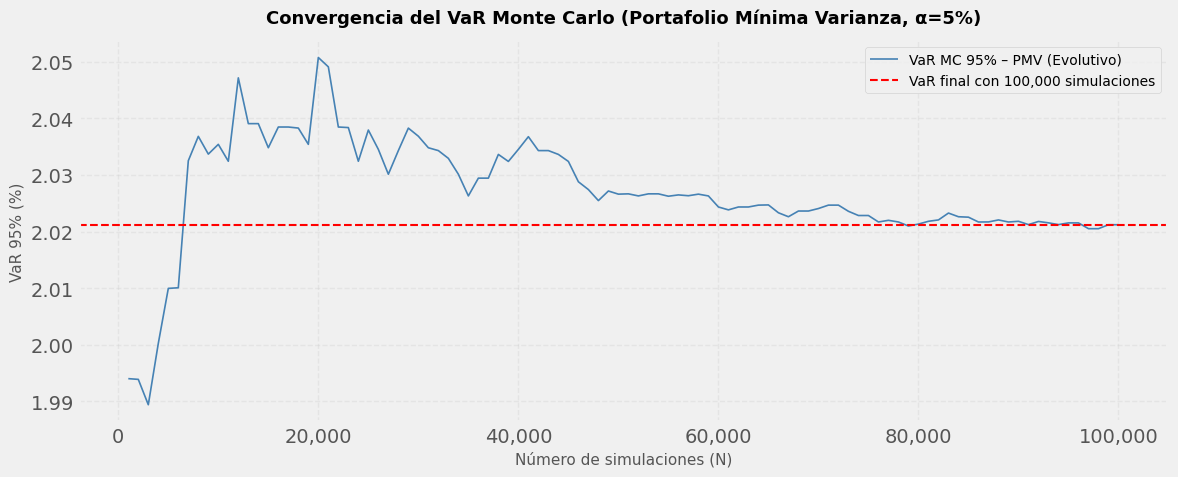

In [16]:
# =============================================================================
# 12. Convergencia del VaR para el método Monte Carlo
# =============================================================================
"""
VERIFICACIÓN DE CONVERGENCIA:

De acuerdo a la ley de los grandes números,
a medida que aumenta el número de simulaciones,
las estimaciones del VaR tienden a estabilizarse.
Esto permite verificar si el tamaño de la muestra
utilizado en Monte Carlo es suficientemente grande
para obtener resultados consistentes y confiables.

"""
print("\n" + "="*70)
print("Convergencia del VaR para el método de Monte Carlo")
print("="*70)

# Generamos tamaños de muestra en incrementos de 1,000 (desde 1,000 hasta 100,000)
muestras = np.arange(1000, N_SIMULACIONES + 1, 1000)

# Calculamos dinámicamente el VaR al 95% recortando el array simulado [:n]
var_convergencia = [
    calcular_var(rendimientos_minvar_sim[:n], 0.05) for n in muestras
]

# Construcción de la gráfica de convergencia
fig, ax = plt.subplots(figsize=(12, 5))

# Línea del proceso de estabilización (en porcentaje)
ax.plot(muestras, np.array(var_convergencia) * 100, color="steelblue",
        linewidth=1.2, label="VaR MC 95% – PMV (Evolutivo)")

# Línea base horizontal con el VaR final de tus 100,000 simulaciones
ax.axhline(
    calcular_var(rendimientos_minvar_sim, 0.05) * 100,
    color="red", linewidth=1.5, linestyle="--",
    label=f"VaR final con {N_SIMULACIONES:,} simulaciones"
)

# Formateo y personalización estética de los ejes
ax.set_xlabel("Número de simulaciones (N)", fontsize=11)
ax.set_ylabel("VaR 95% (%)", fontsize=11)
ax.set_title("Convergencia del VaR Monte Carlo (Portafolio Mínima Varianza, α=5%)",
             fontsize=13, fontweight="bold", pad=12)

# Modificar el formato del eje X para que muestre comas en los miles (10,000, 20,000...)
ax.get_xaxis().set_major_formatter(plt.FuncFormatter(lambda x, loc: "{:,}".format(int(x))))

ax.legend(fontsize=10, loc="upper right")
ax.grid(True, alpha=0.3, linestyle="--")

plt.tight_layout()



**Interpretación de la Convergencia del VaR Monte Carlo:**

La gráfica tiene dos líneas: una roja punteada (el VaR final con las 100,000 simulaciones, que es 2.0212% de VaR) y una azul continua (cómo se va calculando el VaR conforme se agregan más simulaciones).

Al inicio (Muestras pequeñas - de 0 a 20,000 simulaciones): La línea azul empieza abajo, pero luego da un salto enorme hacia arriba y llega a su punto más alto (2.05%) justo en las 20,000 simulaciones. Esto pasa porque con poquitas simulaciones el azar domina el modelo. Si nos hubiéramos detenido ahí, el VaR estaría mal calculado (sobreestimado) por culpa del ruido muestral.

En medio (Estabilización - de 20,000 a 60,000 simulaciones): La línea azul empieza a bajar y a calmarse. El azar pierde fuerza porque los nuevos escenarios se empiezan a promediar con los anteriores.

Al final (Convergencia absoluta - de 60,000 a 100,000 simulaciones): Al pasar las 60,000 simulaciones, la línea azul se "aplancha" por completo. Se vuelve una línea recta horizontal que se pega casi a la perfección sobre la línea roja. Esto demuestra que 100,000 simulaciones son más que suficientes, ya que el resultado dejó de cambiar y se volvió totalmente estable.



**Resultados del VaR Monte Carlo: INTERPRETACIÓN**



Para el portafolio de mínima varianza compuesto por FEMSA (42.88%), WALMEX (27.95%), BIMBO (15.94%), BANORTE (8.71%) y TELEVISA (4.51%), se obtuvieron los siguientes resultados:

Con un 95% de confianza, la pérdida máxima diaria del portafolio no superará el 0.020212 y con un 90% de confianza, la pérdida máxima diaria no superará el
0.015665.

La media del portafolio es positiva (0.0660% diario), lo que indica que el portafolio no solo minimiza el riesgo sino que también genera rendimientos positivos esperados, asimismo se tiene una volatilidad controlada de 1.2801%. diario.

**Matriz de Covarianza y Cholesky:**
Se observa que la matriz es "positiva definida", lo cual significa que es matenáticamente consistente para simular escenarios reales. Por lo que se está usando para que las simulaciones respten las correlaciones históricas entre las acciones (por ejemplo, si BIMBO y FEMSA suelen subir juntas, nuestra simulación lo replicará).

Por otro lado, en este modelo se simularon 100, 000 escenarios posibles a partir de los precios actuales de las acciones.

Con respecto, a las estadísticas de los portafolios simulados se observó lo siguiente:

**Portafolio de Mínima Variazna (Markowitz):** Busca minimizar el riesgo.

**Portafolio Equiponderado:** Asigna el mismo peso (20%) a cada una de las 5 acciones.

**Rendimientos:** El portafolio de Mínima Varianza tiene un rendimiento promedio simulado de 0.0632% diario mientras que el Equiponderado da 0.0241%.

**Volatilidad**: El de Mínima Varianza tiene un 1.2823%, y el Equipondearado un 1.2298%.


**Interpretación del VaR:**

El VaR nos ayuda a decir cuánto es lo máximo que se podría perder en un solo día bajo condiciones normales del mercado, dado un nivel de confianza, por lo que para nuestro modelo se calcula bajo una inversión hipotética de $10, 000 MXN.

Con un nivel de confianza del 95% (Alpha = 5%):

 significa que hay un 95% de probabilidades de que las pérdidas diarias no superen estos montos (o bien que el 5% de los peores días se perderá más que esto):

*   **Portafolio de Mínima Varianza:** El VaR de Monte Carlo es de 202.12 MXN. Existe un 5% de probabilidad de que en un día se pierda más de 202.12 pesos de los $10, 000 invertidos.
*   **Portafolio equiponderado:** El VaR de Monte Carlo es de 1.9857% (aprox 198.57 MXN). Es ligeramente más seguro para un día extremo bajo este nivel de confianza.

Con un nivel de confianza del 90% (Alpha = 10%): Aquí es menos estrcicto con el escenario extremo, por lo que la pérdida máxima estimada disminuye.



*  **Portafolio Mínima Varianza:** El VaR de Monte Carlo baja a 1.5665%
*  En dinero, 156.65 MXN significa que el 90% de los días las pérdidas serán menores a 156.65 pesos.

**Portafolio Equiponderado:** El VaR de Monte Carlo es de 1.5454% (aprox. $154.54 MXN).



**Interpretación de las gráficas:** Todo lo que está a la izquierda de la línea roja representa ese 5% de pérdidas extremas. Al ver que ambas campanas son esbeltas y las líneas no están tan alejadas del centro, indica que ambos portafolios están bien diversificados y no muestran riesgos de pérdidas  descontroladas en el corto plazo.



# 8. Resultados y análisis


Comparar los distintos VaR y analizar diferencias entre métodos. Decir con que métodos se
quedarían y por qué.

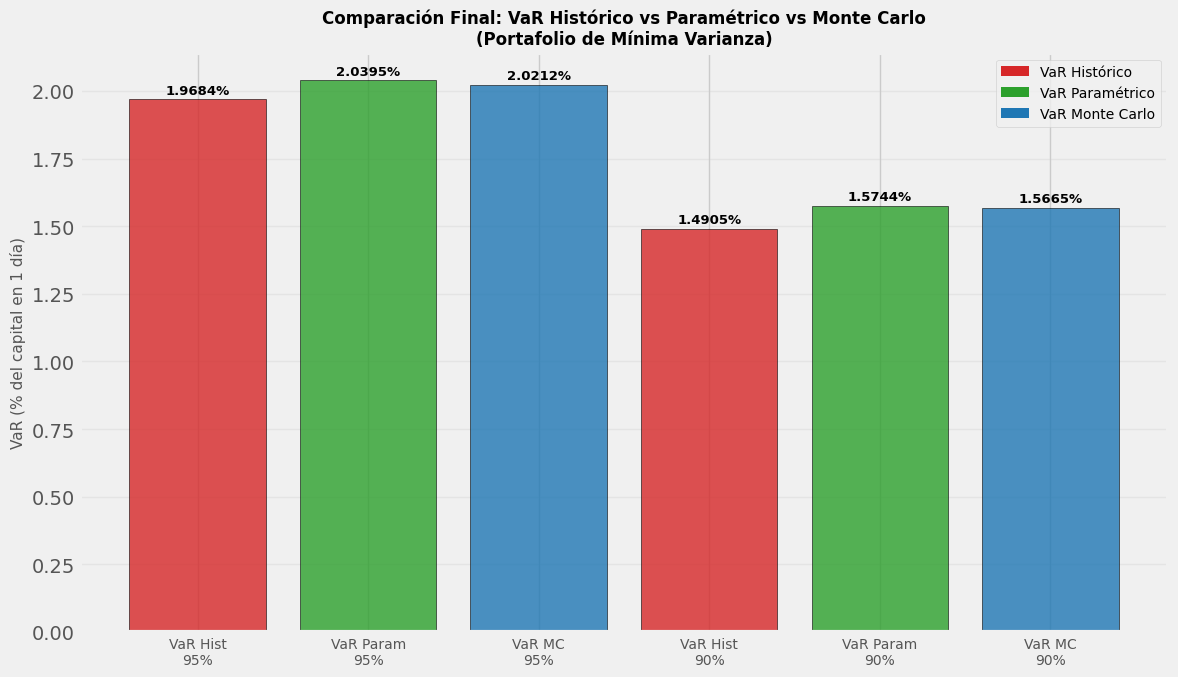


----------------------------------------------------------------------
TABLA 1: COMPARACIÓN DE VaR SEGÚN MÉTODO
----------------------------------------------------------------------
         Método VaR 95% VaR 90% Diferencia (95% vs 90%)
  VaR Histórico   1.97%   1.49%                 0.48 pp
VaR Paramétrico   2.04%   1.57%                 0.47 pp
VaR Monte Carlo   2.02%   1.57%                 0.45 pp
----------------------------------------------------------------------


In [17]:
# =============================================================================
# PUNTO 8: GRÁFICA DE COMPARACIÓN FINAL DE LOS TRES MÉTODOS (VaR)
# =============================================================================

import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy.stats import norm
import numpy as np
import pandas as pd

# Definimos la figura y los ejes

fig, ax = plt.subplots(figsize=(12, 7))

# Definimos las etiquetas del eje X para los métodos y niveles de confianza
metodos = [
    "VaR Hist\n95%", "VaR Param\n95%", "VaR MC\n95%",
    "VaR Hist\n90%", "VaR Param\n90%", "VaR MC\n90%"
]

# --- Cálculo dinámico con las variables de la simulación ---
# Z crítico para el VaR paramétrico
z_95 = norm.ppf(0.05)
z_90 = norm.ppf(0.10)

val_mv = [
    # --- Niveles al 95% (alfa = 0.05) ---
    -np.percentile(retornos_historicos_minvar, 5) * 100, # Histórico
    -(retornos_historicos_minvar.mean() + z_95 * retornos_historicos_minvar.std()) * 100, # Paramétrico
    calcular_var(rendimientos_minvar_sim, 0.05) * 100, # Monte Carlo

    # --- Niveles al 90% (alfa = 0.10) ---
    -np.percentile(retornos_historicos_minvar, 10) * 100, # Histórico
    -(retornos_historicos_minvar.mean() + z_90 * retornos_historicos_minvar.std()) * 100, # Paramétrico
    calcular_var(rendimientos_minvar_sim, 0.10) * 100 # Monte Carlo
]

# Construcción de la gráfica de barras
x = np.arange(len(metodos))
# Colores: Rojo (Histórico), Verde (Paramétrico), Azul (Monte Carlo)
barras = ax.bar(x, val_mv, color=["#d62728", "#2ca02c", "#1f77b4"] * 2,
                alpha=0.8, edgecolor="black", linewidth=0.5)

# Agregar las etiquetas de porcentaje sobre cada barra
for bar, val in zip(barras, val_mv):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
            f"{val:.4f}%", ha="center", va="bottom", fontsize=9.5, fontweight="bold")

# Configuraciones de los ejes y títulos
ax.set_xticks(x)
ax.set_xticklabels(metodos, fontsize=10)
ax.set_ylabel("VaR (% del capital en 1 día)", fontsize=11)
ax.set_title("Comparación Final: VaR Histórico vs Paramétrico vs Monte Carlo\n(Portafolio de Mínima Varianza)",
             fontsize=12, fontweight="bold")
ax.grid(True, axis="y", alpha=0.3)

# Leyenda personalizada
leyenda = [
    Patch(facecolor="#d62728", label="VaR Histórico"),
    Patch(facecolor="#2ca02c", label="VaR Paramétrico"),
    Patch(facecolor="#1f77b4", label="VaR Monte Carlo"),
]
ax.legend(handles=leyenda, fontsize=10, loc="upper right")

# Ajuste de la imagen
plt.tight_layout()
plt.savefig("grafica_comparacion_final_var.png", dpi=150, bbox_inches="tight")
plt.show()

# ------------------------------------------------------------
# 2. TABLA COMPARATIVA
# ------------------------------------------------------------

print("\n" + "-"*70)
print("TABLA 1: COMPARACIÓN DE VaR SEGÚN MÉTODO")
print("-"*70)

# 1. Valores del VaR al 95% (α = 0.05) - Convertidos a porcentaje directo (*100)
z_95 = norm.ppf(0.05)
v_hist_5  = -np.percentile(retornos_historicos_minvar, 5) * 100
v_param_5 = -(retornos_historicos_minvar.mean() + z_95 * retornos_historicos_minvar.std()) * 100
v_mc_5    = calcular_var(rendimientos_minvar_sim, 0.05) * 100  # Usando tu función nativa

# 2. Valores del VaR al 90% (α = 0.10) - Convertidos a porcentaje directo (*100)
z_90 = norm.ppf(0.10)
v_hist_10  = -np.percentile(retornos_historicos_minvar, 10) * 100
v_param_10 = -(retornos_historicos_minvar.mean() + z_90 * retornos_historicos_minvar.std()) * 100
v_mc_10   = calcular_var(rendimientos_minvar_sim, 0.10) * 100  # Usando tu función nativa

# 3. Construcción de la tabla aplicando la resta directa (95% - 90%)

comparacion = pd.DataFrame({
    'Método': ['VaR Histórico', 'VaR Paramétrico', 'VaR Monte Carlo'],
    'VaR 95%': [f"{v_hist_5:.2f}%",
                f"{v_param_5:.2f}%",
                f"{v_mc_5:.2f}%"],
    'VaR 90%': [f"{v_hist_10:.2f}%",
                f"{v_param_10:.2f}%",
                f"{v_mc_10:.2f}%"],
    'Diferencia (95% vs 90%)': [f"{(v_hist_5 - v_hist_10):.2f} pp",
                                f"{(v_param_5 - v_param_10):.2f} pp",
                                f"{(v_mc_5 - v_mc_10):.2f} pp"]
})

print(comparacion.to_string(index=False))
print("-"*70)



**Comparación de los Métodos**


Al analizar la tabla y los gráficos generados, se pueden destacar tres observaciones clave sobre el comportamiento del riesgo en el portafolio:

**Primera observación: Convergencia entre el VaR Paramétrico y el VaR Monte Carlo**

Al comparar el VaR Paramétrico con el VaR Monte Carlo, se observa que ambos métodos arrojan resultados muy similares. Esta cercanía ocurre porque la simulación Monte Carlo implementada utiliza choques aleatorios generados a partir de una distribución normal mediante el Movimiento Browniano Geométrico. Debido a la gran cantidad de simulaciones realizadas (100,000 iteraciones), los resultados obtenidos mediante simulación tienden a converger hacia los resultados teóricos del modelo paramétrico.

El VaR Paramétrico supone que los rendimientos siguen una distribución normal, mientras que el método Monte Carlo genera escenarios aleatorios utilizando variables normales estándar con media cero y varianza uno. Por ello, al utilizar los mismos parámetros de media, volatilidad y correlación, ambos métodos producen estimaciones de riesgo muy cercanas. Las pequeñas diferencias observadas se explican por el error muestral inherente al proceso de simulación.

**Segunda observación: El VaR Histórico es el más bajo**


El método histórico arrojó el menor nivel de riesgo entre los tres métodos analizados. Esto indica que las pérdidas extremas observadas en los datos históricos fueron ligeramente menores que las estimadas bajo los supuestos de normalidad utilizados por el VaR Paramétrico y Monte Carlo.

Esta diferencia puede explicarse porque el VaR Histórico utiliza únicamente la información observada en el mercado durante el período analizado, mientras que los otros métodos incorporan escenarios probabilísticos teóricos que pueden generar pérdidas más severas. Además, el período estudiado pudo haber presentado una volatilidad relativamente estable, reduciendo así las pérdidas extremas observadas históricamente.

**Tercera observación: Comportamiento consistente entre niveles de confianza**

Cuando se reduce el nivel de confianza de 95% a 90%, la pérdida máxima esperada disminuye de manera similar en los tres métodos, aproximadamente entre 0.45 y 0.48 puntos porcentuales.

El hecho de que esta reducción sea consistente entre métodos sugiere que las pérdidas del portafolio presentan un comportamiento relativamente estable. Esto también indica que el portafolio de mínima varianza se encuentra adecuadamente diversificado y que la estrategia de optimización de Markowitz logró reducir el riesgo total y estabilizar la volatilidad de los rendimientos.

**Análisis de las diferencias entre métodos**

1. ***VaR Histórico:***

Fue el método que dio los valores más bajos de riesgo.
Usa únicamente datos históricos reales.
No supone ninguna distribución probabilística.
Depende completamente del comportamiento pasado del mercado.

Resultados:

VaR 95% = 1.9684%
VaR 90% = 1.4905%

Esto significa que, según los datos históricos, la pérdida máxima esperada en un día sería aproximadamente de 1.97% con 95% de confianza.

2. ***VaR Paramétrico:***

Fue el método más conservador (estima pérdidas mayores de las que probablemente ocurrirán.)
Supone que los rendimientos siguen una distribución normal.
Usa media y desviación estándar del portafolio.

Resultados:

VaR 95% = 2.0395%
VaR 90% = 1.5744%

Las pérdidas estimadas son ligeramente mayores porque el supuesto de normalidad puede sobreestimar el riesgo en algunos casos.

3. ***VaR Monte Carlo:***

Produjo resultados muy cercanos al VaR Paramétrico.
Simula miles de escenarios posibles del mercado.
Considera correlaciones entre activos mediante Cholesky.
Es el método más flexible y robusto.

Resultados:

VaR 95% = 2.0212%
VaR 90% = 1.5665%

Las diferencias respecto al VaR Paramétrico fueron mínimas.


Por lo tanto, esto sugiere que el portafolio tiene un comportamiento relativamente estable y que los distintos métodos coinciden en que el nivel de riesgo del portafolio es moderado.


**¿Con qué métodos se quedarían y por qué?**

Aunque los tres métodos produjeron resultados muy similares, el método con el que nos quedaríamos sería el VaR Monte Carlo.

La principal razón es que este método es el más flexible y robusto de los tres enfoques analizados, ya que permite simular miles de escenarios posibles del comportamiento futuro del mercado incorporando tanto la volatilidad individual de cada activo como las correlaciones entre ellos mediante la descomposición de Cholesky.

A diferencia del VaR Histórico, el método Monte Carlo no depende exclusivamente de eventos observados en el pasado, por lo que puede generar escenarios adicionales que no necesariamente ocurrieron históricamente. Lo cual lo convierte en una herramienta más completa para la medir el VaR.

Asimismo, aunque el VaR Paramétrico también utiliza supuestos de normalidad y produjo resultados muy cercanos, el método Monte Carlo tiene la ventaja de ser más adaptable ya que este cumple con más supuestos que hacen que al modelar el VaR el resultado sea mejor.

Con lo anterio, podemos decir que aunque los tres métodos fueron consistentes y válidos para medir el VaR, consideramos que el método Monte Carlo representa la alternativa más completa y flexible para la estimación del riesgo financiero, especialmente en contextos donde se desea modelar escenarios complejos e incorporar la dependencia entre activos.